# Exploratory Data Analysis (EDA)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/hr_employee_churn_data.csv")

In [4]:
df.head()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   empid                  14999 non-null  int64  
 1   satisfaction_level     14997 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  str    
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(7), str(1)
memory usage: 1.1 MB


In [7]:
df.describe()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,left
count,14999.000000,14997.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7500.000000,0.612863,0.716102,3.803054,201.050337,3.498233,0.144610,0.021268,0.238083
std,4329.982679,0.248634,0.171169,1.232592,49.943099,1.460136,0.351719,0.144281,0.425924
min,1.000000,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,3750.500000,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,7500.000000,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,11249.500000,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,14999.000000,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
df["Work_accident"].unique()

array([0, 1])

In [9]:
df["promotion_last_5years"].unique()

array([0, 1])

## Рассмотрим категориальные признаки

<Axes: xlabel='left', ylabel='count'>

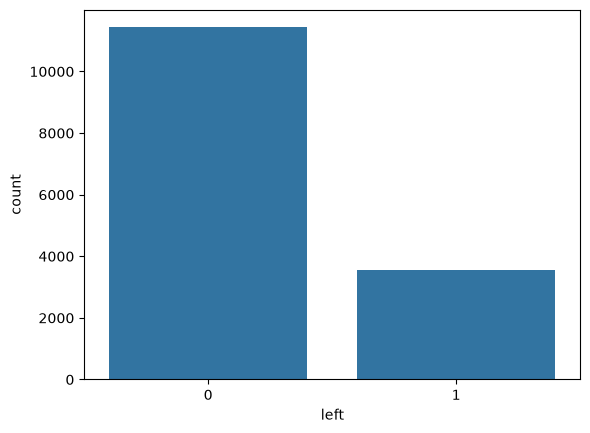

In [ ]:
# Выведем схему, которая покажет сколько сотрудников уволилось, а сколько осталось
sns.countplot(x="left", data=df)

Наглядно видно, что сотрудников уволилось меньше, чем осталось - дисбаланс.

<Axes: xlabel='salary', ylabel='count'>

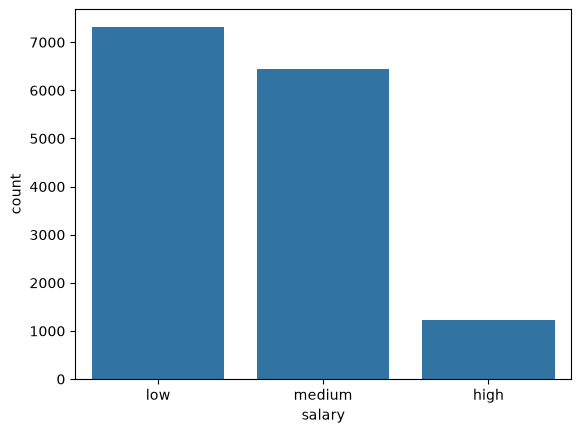

In [12]:
sns.countplot(x="salary", data=df)

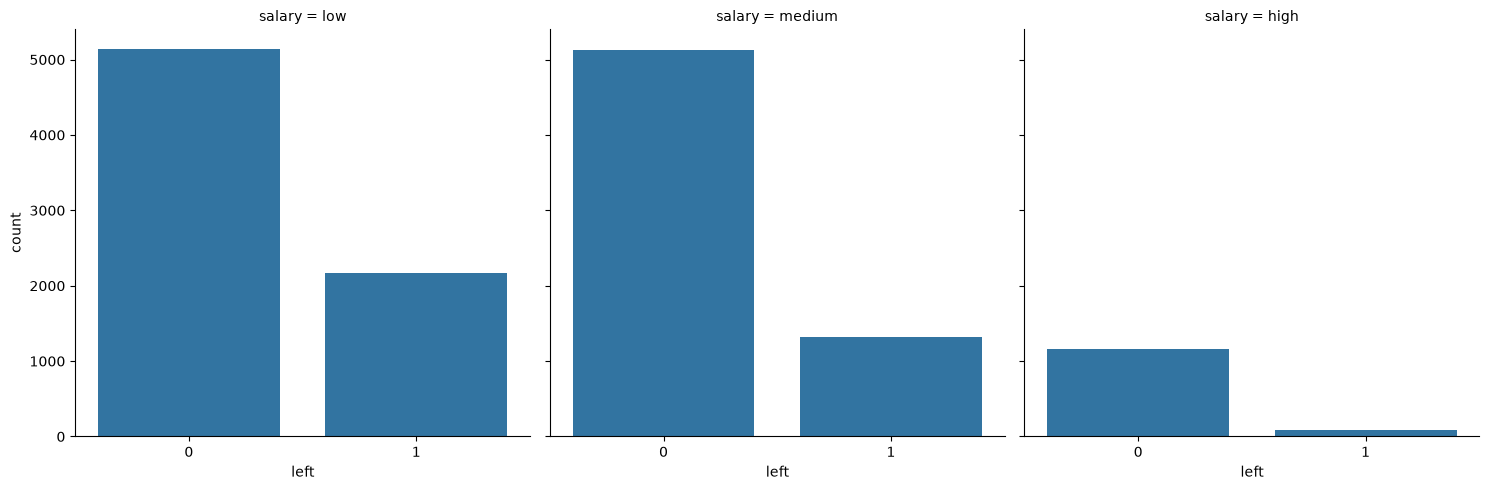

In [13]:
sns.catplot(x="left", col="salary", kind="count", data=df)

Большинство ушедших сотрудников зарабатывали мало

<Axes: xlabel='promotion_last_5years', ylabel='count'>

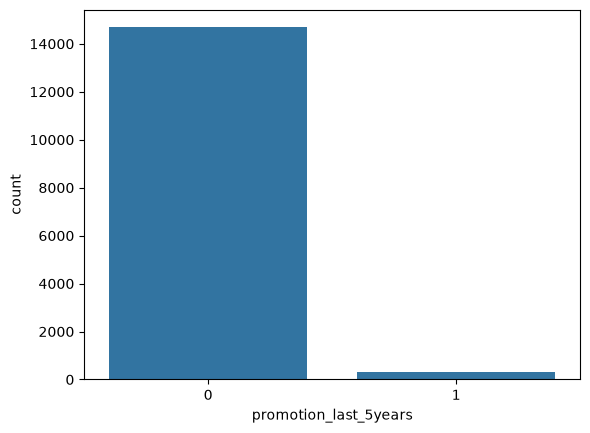

In [15]:
sns.countplot(x="promotion_last_5years", data=df)

Сотрудников получивших повышение очень мало

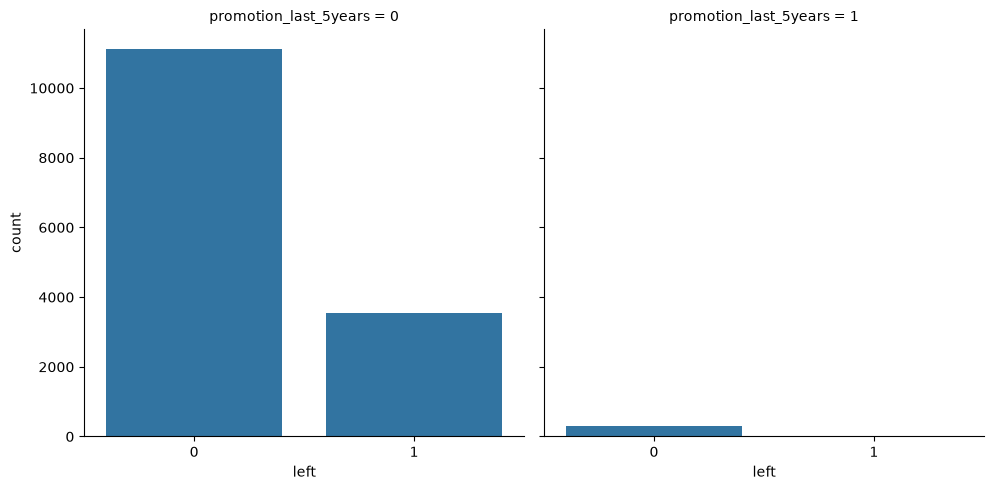

In [16]:
sns.catplot(x="left", col="promotion_last_5years", kind="count", data=df)

Получившие повышение сотрудники вообще не увольнялись

<Axes: xlabel='Work_accident', ylabel='count'>

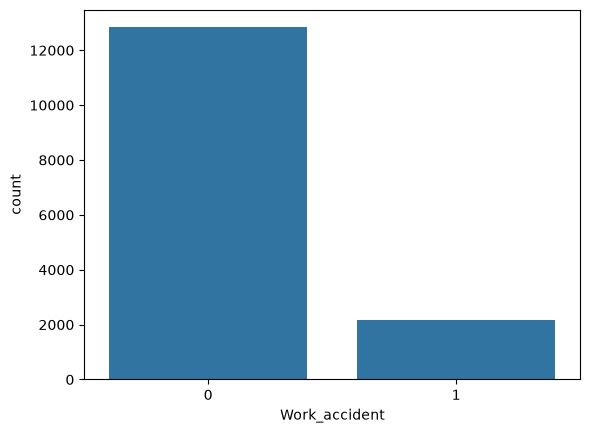

In [17]:
sns.countplot(x="Work_accident", data=df)

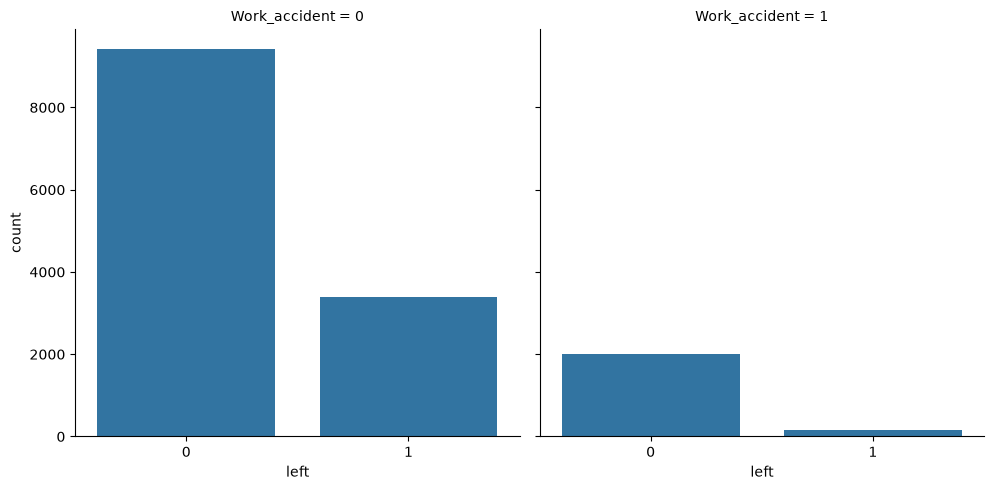

In [18]:
sns.catplot(x="left", col="Work_accident", kind="count", data=df)

Отсутствие опыта рабочего инцидента никак не влияет на уход кадров - если не было инцидентов, работник всё равно часто уходил, если было, работник тоже мог уйти. **Этот признак не будем использовать**.

## Перейдём к количественным признакам

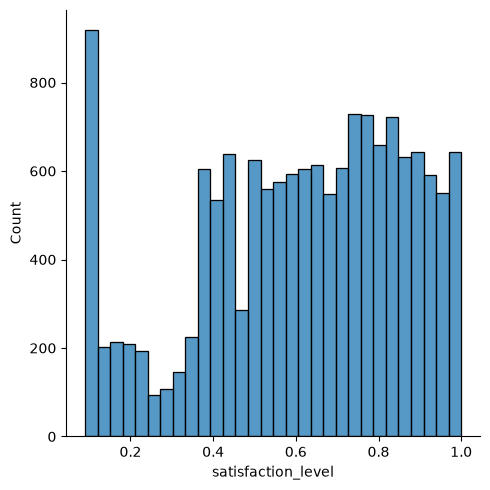

In [ ]:
# sns.distplot(df["satisfaction_level"])  # Удалённая функция в современной версии библиотеки
sns.displot(df["satisfaction_level"])

<Axes: xlabel='left', ylabel='satisfaction_level'>

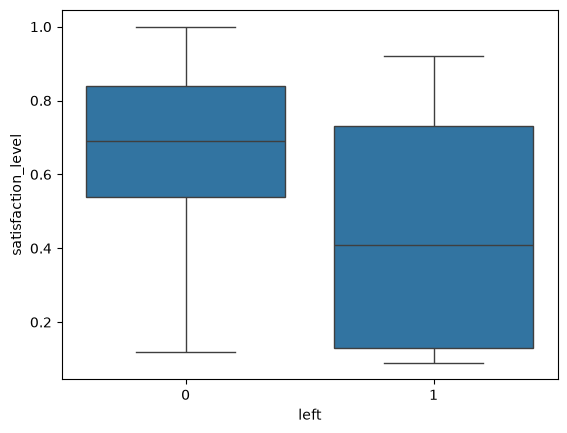

In [24]:
sns.boxplot(x="left", y="satisfaction_level", data=df)

In [25]:
df["satisfaction_level"].mean()

np.float64(0.6128625725145029)

Общий уровень удовлетворённости средний, однако большинство сотрудников имеет маленький коэффициент удовлетворённости, более того сотрудники с большим значением меньше увольнялись

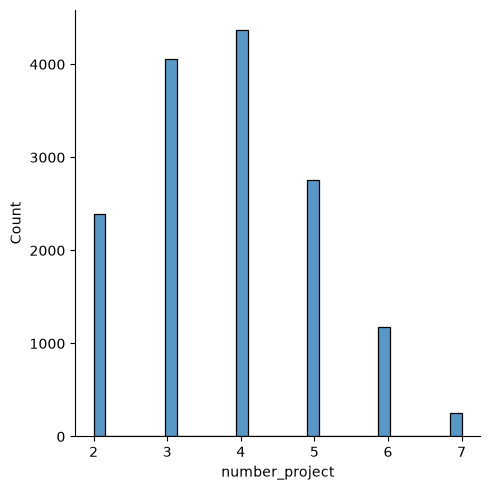

In [26]:
sns.displot(df["number_project"])

<Axes: xlabel='left', ylabel='number_project'>

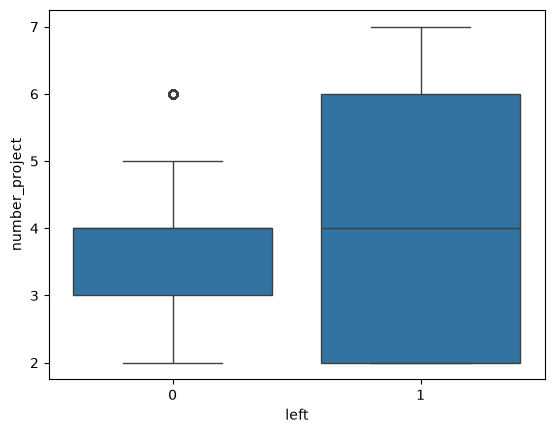

In [27]:
sns.boxplot(x="left", y="number_project", data=df)

Проектов может быть от 2 до 7, среднее - 3, 4 проекта у сотрудника. У уволившихся сотрудников проектов самое разное количество, а у оставшихся не более 4

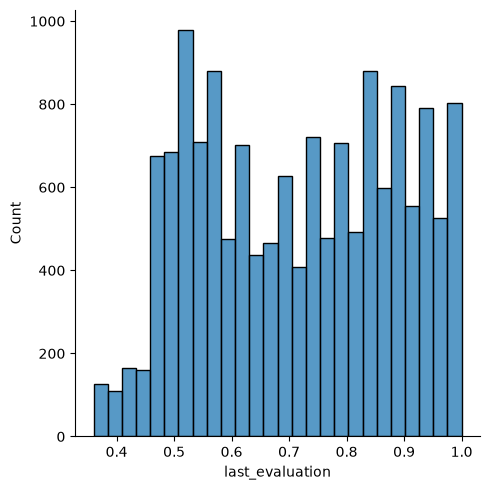

In [28]:
sns.displot(df["last_evaluation"])

<Axes: xlabel='left', ylabel='last_evaluation'>

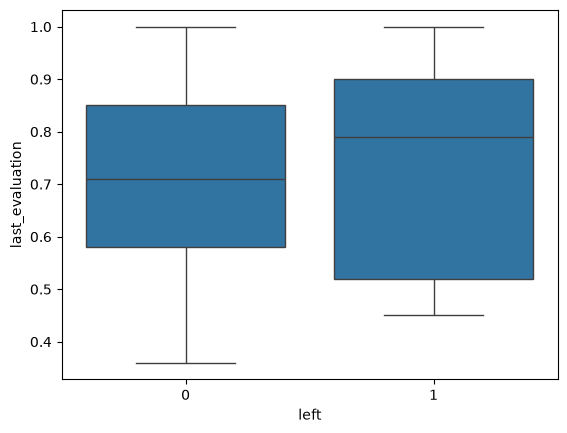

In [29]:
sns.boxplot(x="left", y="last_evaluation", data=df)

Не сильно влияет на увольнения. Что интересно, у уволившихся сотрудников оценка могла быть как выше, так и ниже, чем у оставшихся

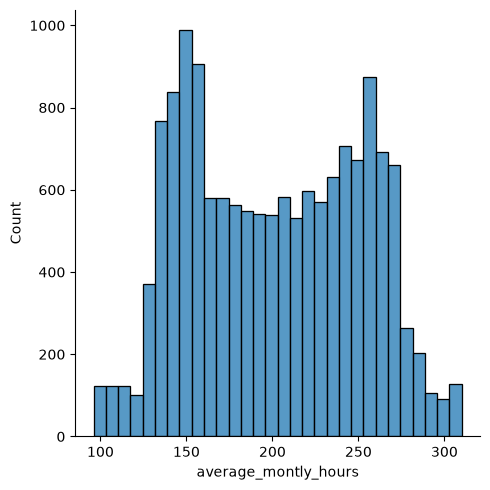

In [30]:
sns.displot(df["average_montly_hours"])

<Axes: xlabel='left', ylabel='average_montly_hours'>

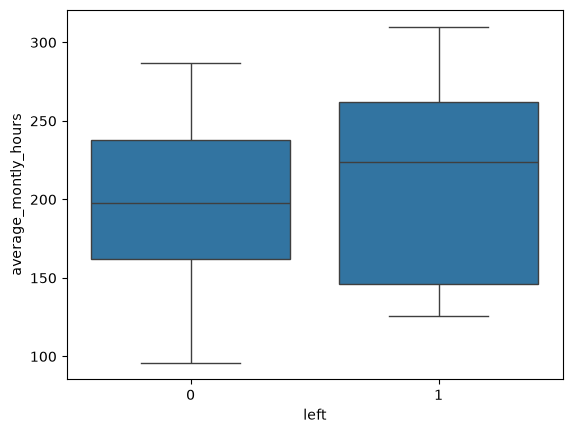

In [31]:
sns.boxplot(x="left", y="average_montly_hours", data=df)

Аналогично с предыдущим признаком

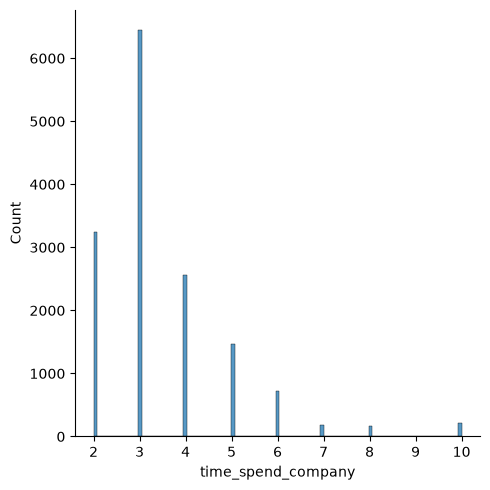

In [32]:
sns.displot(df["time_spend_company"])

<Axes: xlabel='left', ylabel='time_spend_company'>

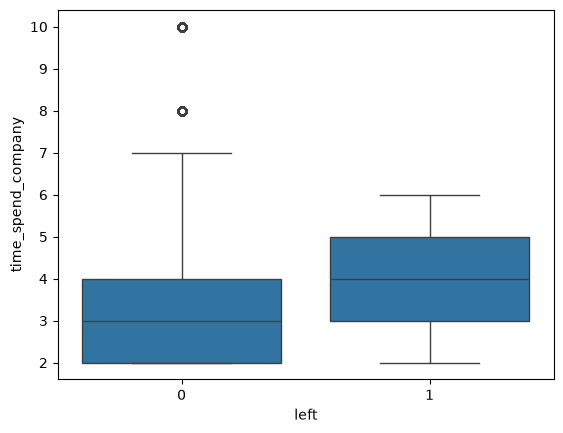

In [33]:
sns.boxplot(x="left", y="time_spend_company", data=df)

Уволившиеся сотрудники провели в компании больше времени, чем оставшиеся

## Попробуем увидеть корреляцию между этими признаками, построив тепловую карту

In [36]:
df['salary'] = df['salary'].map({'low': 0, 'medium': 1, 'high': 2})  # Маппим строки в числа, чтобы корреляция могла быть выстроена по числовым значениям

<Axes: >

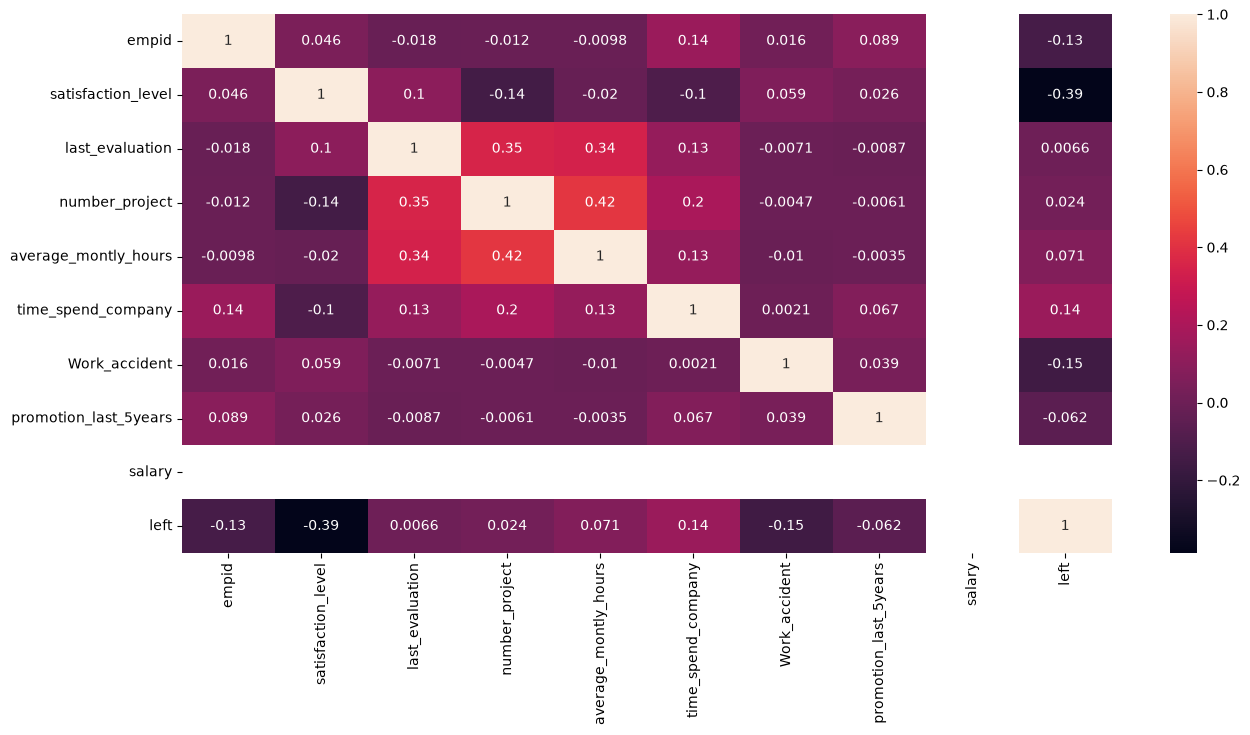

In [37]:
cor_mat = df.corr()
fig = plt.figure(figsize=(15,7))
sns.heatmap(cor_mat, annot=True)

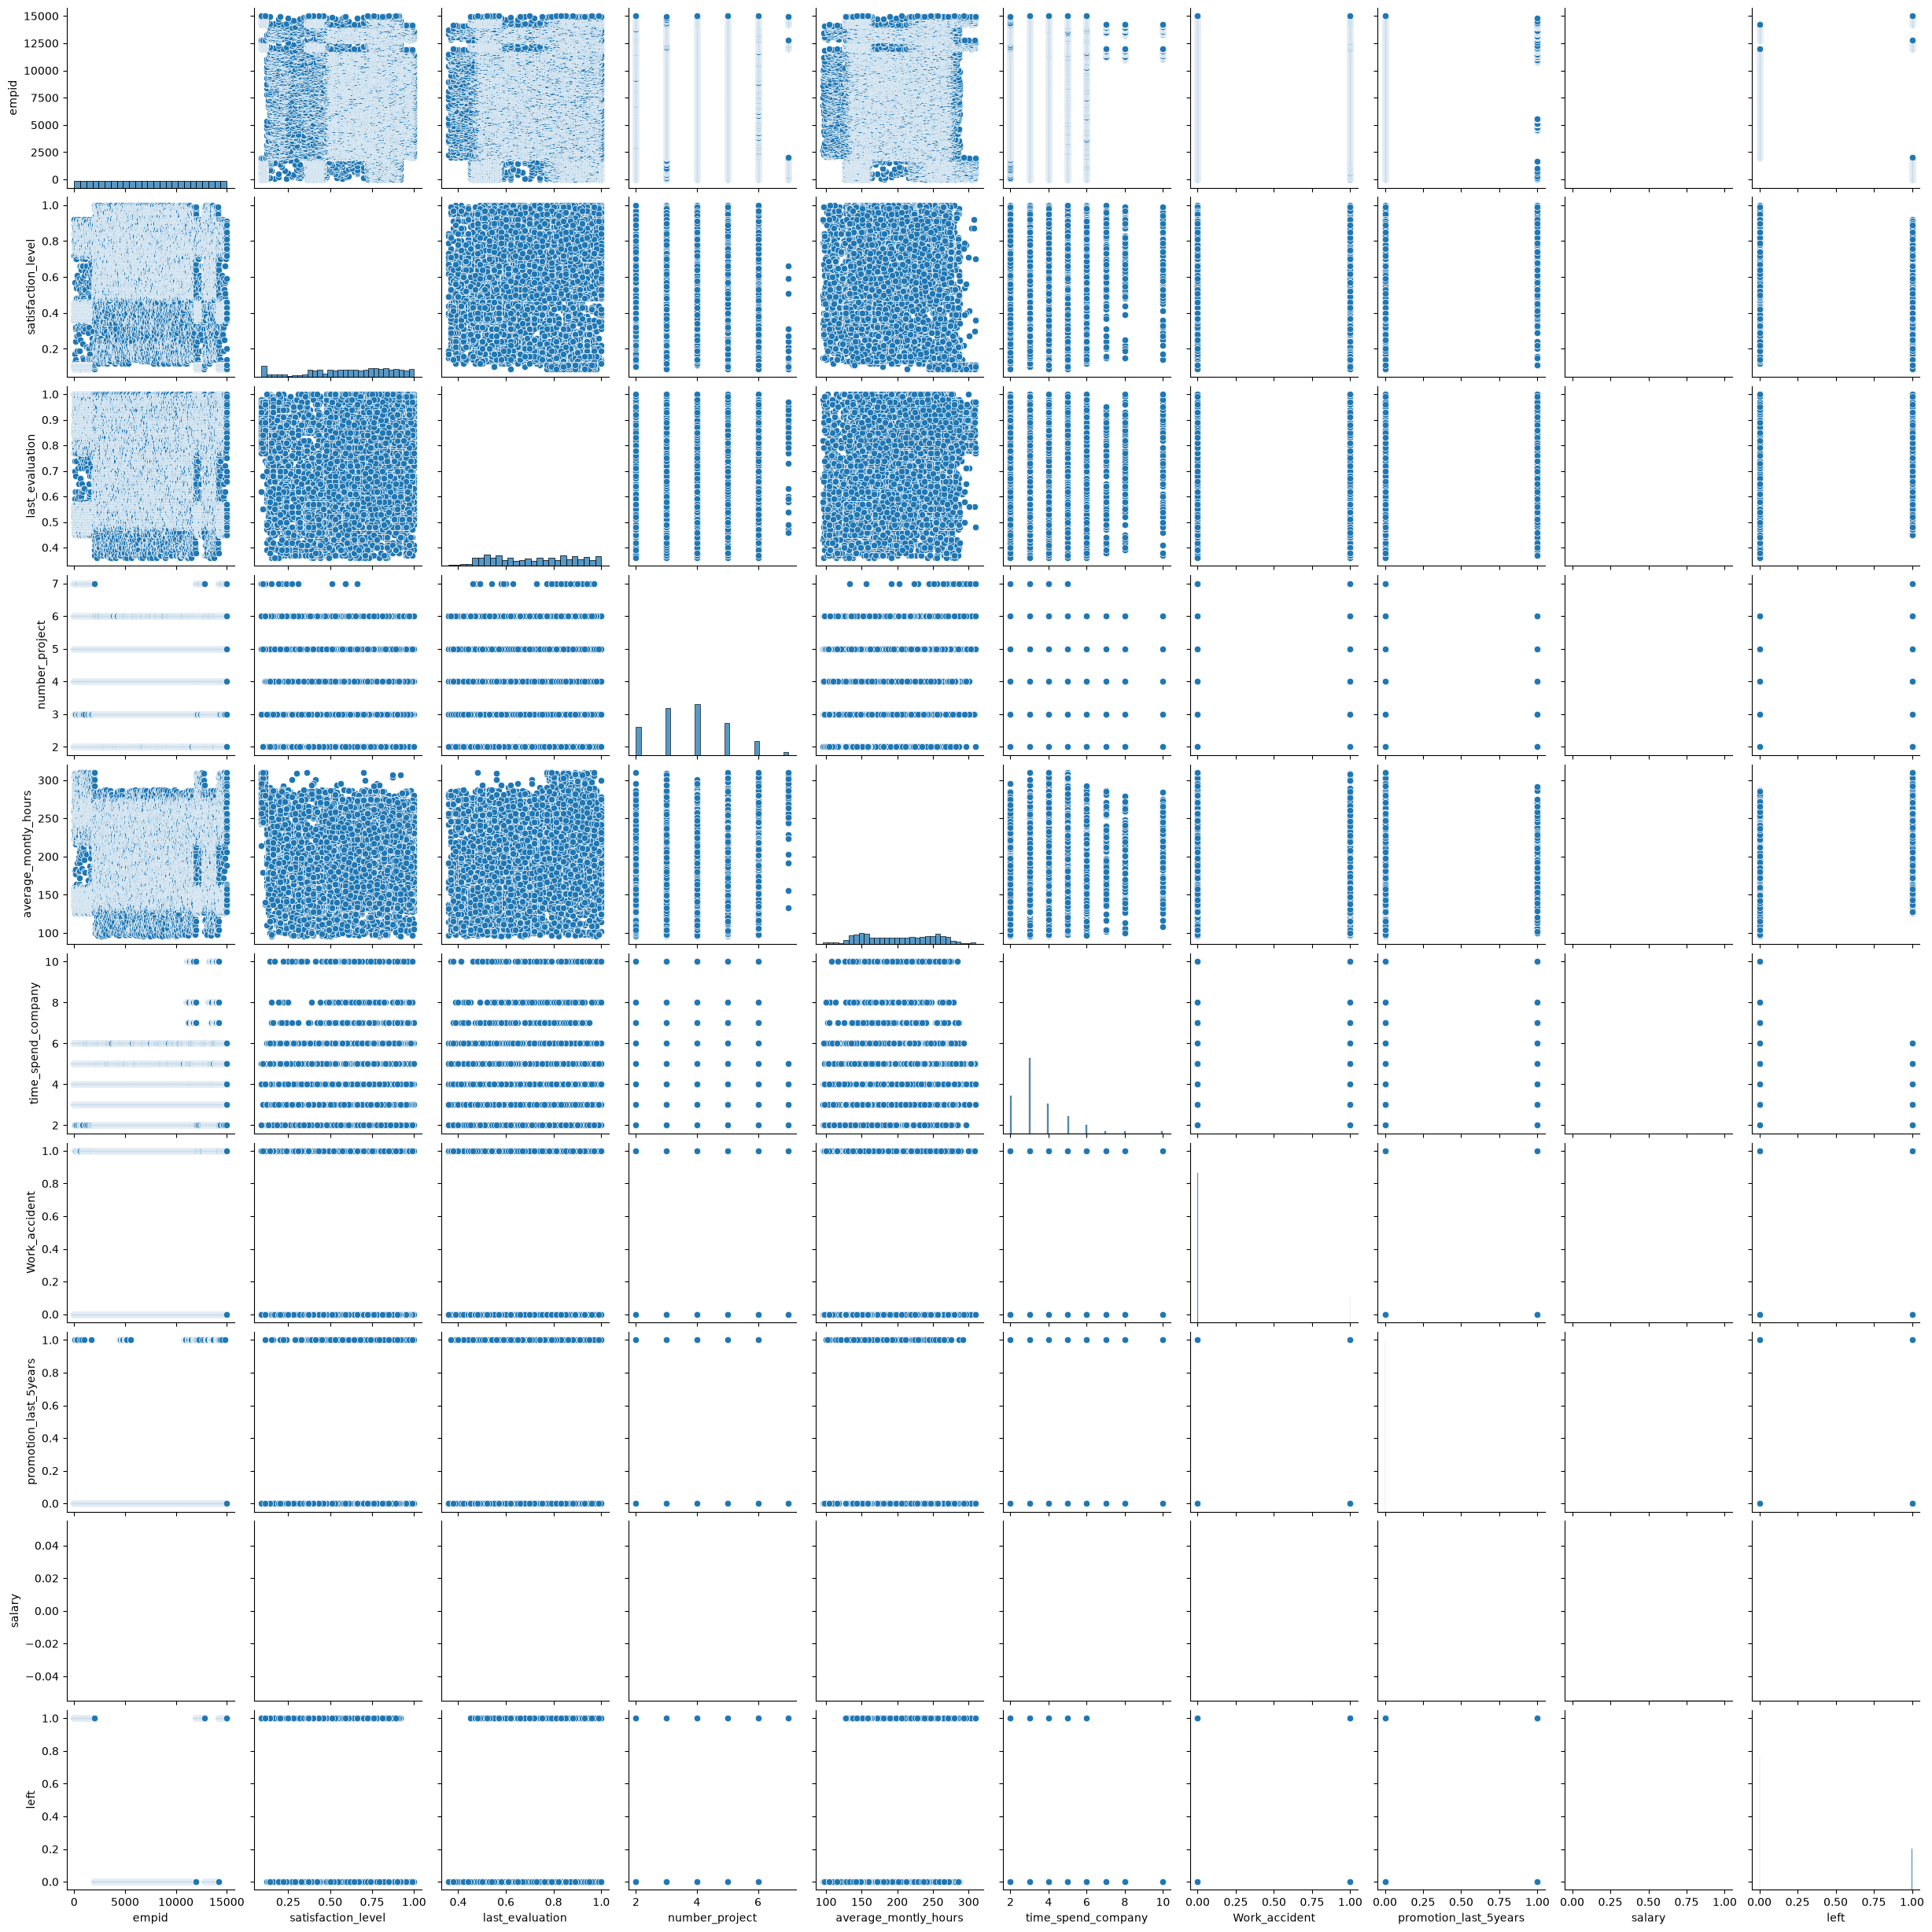

In [38]:
sns.pairplot(df)